# Classification on CIFAR 10 Dataset

Instructions - 
1. In order to kick start, code for setting up the dataframes has already been given (Step 1 to 5)
2. Go through the entire code written below and put the relavent comment for each line of code. Understanding below mentioned code is very important.
3. After commenting the code in step 1 to 5, complete step 6 and 7

https://towardsdatascience.com/cifar-100-pre-processing-for-image-recognition-task-68015b43d658

### Step - 1 (Setup Code)

In [1]:
# Run some setup code for this notebook.
from __future__ import print_function

import random
import numpy as np
import matplotlib.pyplot as plt
import os

from builtins import range
from six.moves import cPickle as pickle
from imageio import imread
import platform

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload module is not an IPython extension.


UsageError: Line magic function `%autoreload` not found.


### Step - 2 (Download the dataset)

In [3]:
# # Use this code to download the dataset for the first time
# # You will be required to install wget using pip
# # For Linux users checkout the alternative for 'del'

# !wget http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz -O cifar-10-python.tar.gz
# !tar -xzvf cifar-10-python.tar.gz
# !del cifar-10-python.tar.gz          

!pip install wget

In [4]:
import wget

print('Beginning file download with wget module')

url = 'http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
wget.download(url,  r'C:\Users\HP\Desktop\Innomatics_Internship\day18_Task2')

Beginning file download with wget module
 17% [............                                                          ]  29958144 / 170498071

KeyboardInterrupt: 

In [10]:
!tar -xzvf cifar-10-python.tar.gz

x cifar-10-batches-py/
x cifar-10-batches-py/data_batch_4
x cifar-10-batches-py/readme.html
x cifar-10-batches-py/test_batch
x cifar-10-batches-py/data_batch_3
x cifar-10-batches-py/batches.meta
x cifar-10-batches-py/data_batch_2
x cifar-10-batches-py/data_batch_5
x cifar-10-batches-py/data_batch_1


In [11]:
!del cifar-10-python.tar.gz         

### Step - 3 (Load the Dataset)

In [5]:
# This cell loads the training and testing dataset. Please note the variables at
# the end of the cell as you would require them to access the train/test data 
# and labels throughout the assignment.
def load_pickle(f):
    version = platform.python_version_tuple()
    if version[0] == '2':
        return  pickle.load(f)
    elif version[0] == '3':
        return  pickle.load(f, encoding='latin1')
    raise ValueError("invalid python version: {}".format(version))


def load_CIFAR_batch(filename):
    """ load single batch of cifar """
    with open(filename, 'rb') as f:
        datadict = load_pickle(f)
        X = datadict['data']
        Y = datadict['labels']
        X = X.reshape(10000, 3, 32, 32).transpose(0,2,3,1).astype("float")
        Y = np.array(Y)
        return X, Y


def load_CIFAR10(ROOT):
    """ load all of cifar """
    xs = []
    ys = []
    for b in range(1,6):
        f = os.path.join(ROOT, 'data_batch_%d' % (b, ))
        X, Y = load_CIFAR_batch(f)
        xs.append(X)
        ys.append(Y)
    Xtr = np.concatenate(xs)
    Ytr = np.concatenate(ys)
    del X, Y
    Xte, Yte = load_CIFAR_batch(os.path.join(ROOT, 'test_batch'))
    return Xtr, Ytr, Xte, Yte


cifar10_dir = 'cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times
try:
    del X_train, y_train
    del X_test, y_test
    print('Clear previously loaded data.')
except:
    pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


### Step - 4 (Visualization)

Next we visualize the CIFAR-10 dataset. Although these functions are being written for you, we highly recommend you go through the code and make yourself familiar as these are things you will be required to do very often when working on AI/ML projects

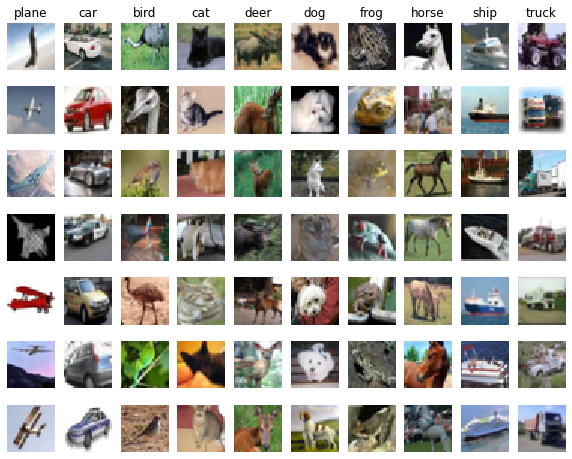

In [6]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

### Step - 5 (Flattening the images)

In the next cell we flatten each image into a single dimensional vector so that it is easy to process. You should be able to reason about the dimensions comfortable.

In [7]:
# Subsample the data for more efficient code execution in this exercise
num_training = 5000
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

# Reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


### Step - 6 (Apply all possible classification algorithms)

For each algo complete the following steps with appropriate plots, diagrams and code - 
1. Discuss the intuition behind each algorithm
2. Mention pros and cons
3. Discuss about Model parameters and Hyperparameters
4. Discuss about overfitting and underfitting with relavant plots and code (Hint: Use cross validation and plot hyperparameter vs accuracy score)
5. Discuss about train and test time/space complexities
6. Measure the performance of model using various metrics and write in detail about each metric

### Logistic Regression
https://towardsdatascience.com/inside-logistic-regression-9312e22d319d

https://en.wikipedia.org/wiki/Logistic_regression#Formal_mathematical_specification

https://towardsdatascience.com/logistic-regression-fa1a86270eb

geometry intuition:
- https://medium.com/analytics-vidhya/geometric-intuition-of-logistic-regression-2e2b57781743
- https://towardsdatascience.com/demystifying-logistic-regression-ee24c1104d45

Logistic Regression is classification model and belongs to a family of generalised linear model (GLM)
- Used when the target variable is discrete or categorical.

Why not Linear and Why Logistic Regression?
- Linear Regression is used to predict a real-valued output anywhere between +∞ and -∞.
- If we decide to apply a linear regression model to predict only 2 classes o.e. 0 and 1, the output ranges are not acceptable because, linear regression gives predictiob ranging between +∞ and -∞, whereas in our case y, the target variable takes only two discrete values, 0 and 1.
- whenever you try to fit a Regression hypothesis curve to a discrete data and introduces an outlier, the line will try to fit the outlier and by making so you need to change your hypothesis threshold. 


So we need to extend the concepts of linear regression to fulfil the requirement.
One approach is to take the output of linear regression and map it between 0 and 1, if the resultant output is below a certain threshold,we can  classify the example as a negative class whereas if the resultant output is above a certain threshold, classify the example as a positive class. 

We will crunch the real-valued output obtained from a linear regression model between 0 and 1 and classify a new example based on a threshold value. The function used to perform this mapping is the **sigmoid function.**

$$fsigmoid(x)= \frac{1}{1+e^{-x}}$$

The graph shows that the sigmoid function has successfully mapped values from +∞ to -∞ between 0 and 1.

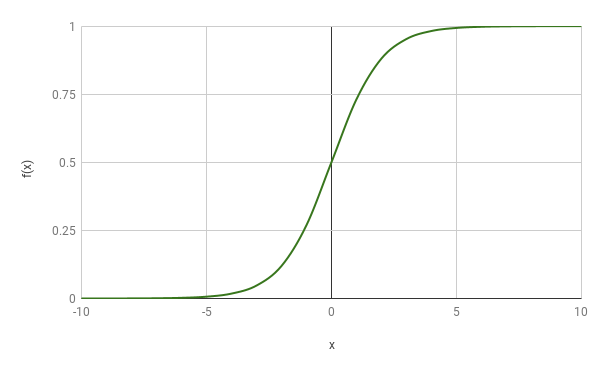

Note that the value of sigmoid function is 0.5 at x=0.
- if x>0 then the value of sigmoid function is >0.5
- if x<0 then the value of sigmoid function is <0.5.
- 0.5 is our threshold.


The logistic model function:

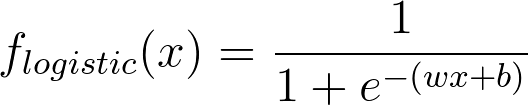

x is the feature vector whereas w and b correspond to the weight and bias respectively. The goal is to find the optimal set of values for w and b.

- In above equation, the output wx+b, from the linear regression model has been passed as an input to the sigmoid function, thereby crunching values ranging from +∞ to -∞ between 0 and 1 and, giving us the model for logistic regression.

- The output of the model is interpreted as the probability of an example x falling into the positive class. Concretely, if for an unseen x the model outputs 0.8, then it implies that, the probability of x being classified as positive is 0.8.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, auc, confusion_matrix, roc_auc_score, roc_curve, recall_score
import scikitplot as skplt
import matplotlib.pyplot as plt

log_reg= LogisticRegression()
log_reg.fit(X_train,y_train)
y_pred_log= log_reg.predict(X_test)   
log_acc=accuracy_score(y_test,y_pred_log)

ModuleNotFoundError: No module named 'scikitplot'

In [15]:
print("Logistic Regression accuracy",log_acc)
print("ROC score on test is: ", roc_auc_score(y_test, test_preds))
skplt.metrics.plot_roc(y_test,log_reg.predict_proba(x_test))
plt.show()


Logistic Regression accuracy 0.324


NameError: name 'roc_auc_score' is not defined

### Naive Bayes
https://medium.com/analytics-vidhya/intuition-behind-naive-bayes-algorithm-laplace-additive-smoothing-e2cb43a82901


Naïve Bayes is a probabilistic machine learning algorithm based on the Bayes Theorem, used in a wide variety of classification tasks.

**Conditional probability** is a measure of the probability of an event occurring given that another event has (by assumption, presumption, assertion, or evidence) occurred.

$$P(A\vert B) = \frac {P(B\vert A) . P(A)}{P(B)}$$

- it tells us how often A happens given that B happens.

**Assumptions of Naive Bayes:**
The fundamental Naïve Bayes assumption is that each feature makes an:

- independent
- equal 

contribution to the outcome.


The assumptions made by Naïve Bayes are generally not correct in real-world situations. The independence assumption is never correct but often works well in practice. Hence the name ‘Naïve’.

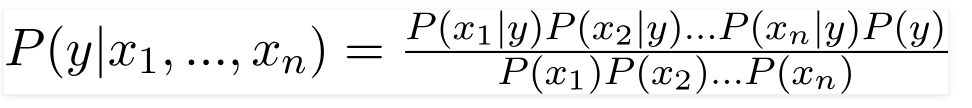

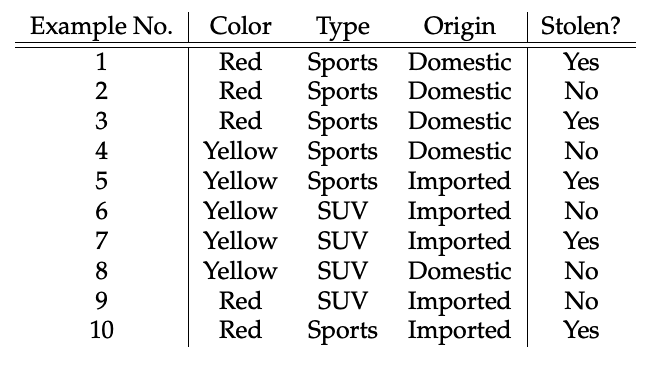

So in our example, we have 3 predictors X.

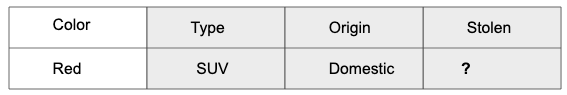

As per the equations discussed above, we can calculate the posterior probability P(Yes | X) as :

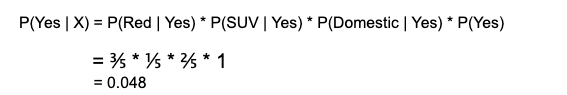

and, P(No | X):

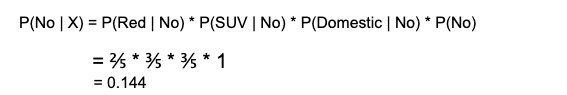

In [8]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

    
# to supress the warning
import warnings
warnings.filterwarnings('ignore')

### Step - 7 (Compare all the models)

Conclude by following below mentioed steps -
1. Plot a table showing all the algorithms used and corresponding performance metrics
2. Is there any one algorithm that can be used on all the datasets? (Hint: Read about 'No Free Lunch' theorem)